1. 在本节的估计问题中使用$\lambda$的值进行实验。绘制训练和测试精度关于$\lambda$的函数。观察到了什么？
1. 使用验证集来找到最佳值$\lambda$。它真的是最优值吗？这有关系吗？
1. 如果我们使用$\sum_i |w_i|$作为我们选择的惩罚（$L_1$正则化），那么更新方程会是什么样子？
1. 我们知道$\|\mathbf{w}\|^2 = \mathbf{w}^\top \mathbf{w}$。能找到类似的矩阵方程吗（见 :numref:`subsec_lin-algebra-norms` 中的Frobenius范数）？
1. 回顾训练误差和泛化误差之间的关系。除了权重衰减、增加训练数据、使用适当复杂度的模型之外，还能想出其他什么方法来处理过拟合？

In [6]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

In [7]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

In [8]:
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

In [9]:
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

In [10]:
def train(lambd):
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 增加了L2范数惩罚项，
            # 广播机制使l2_penalty(w)成为一个长度为batch_size的向量
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是：', torch.norm(w).item())

w的L2范数是： 13.872442245483398


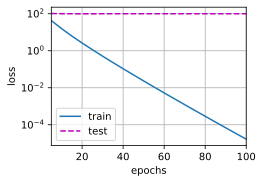

In [11]:
train(lambd=0)

w的L2范数是： 0.3381462097167969


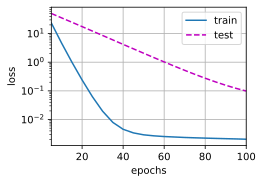

In [12]:
train(lambd=3)

w的L2范数是： 0.03937344625592232


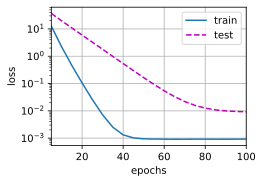

In [13]:
train(lambd=5)

w的L2范数是： 0.0036237742751836777


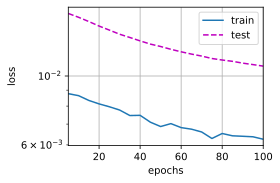

In [15]:
train(lambd=100)

问题一，λ为0时，过拟合严重，随λ增大，泛化能力变好，但过大会导致权重被压缩，发生欠拟合

问题二，不是最优值，由于数据存在随机性和有限样本的影响，验证集得到的结果不一定是真正的全局最优值

问题三，使用L1正则，惩罚函数代码如下

In [16]:
def l1_penalty(w):
    return torch.sum(torch.abs(w))

问题四，矩阵参数的类似形式为 Frobenius范数

In [ ]:
torch.norm(W)**2

问题五，减少过拟合，除了权重衰减之外，还可以通过增加训练数据、降低模型复杂度、使用 Dropout、Early Stopping 或数据增强等方法来减少过拟合。